# AI-Based Smart Exam Proctoring — Suspicious Object Detection (YOLOv8)

**Module:** Object Detection Model Training & Evaluation
**Project:** AI-Based Smart Exam Proctoring & Suspicious Activity Detection System

## Objective
Train a YOLOv8 object detection model to identify exam-integrity risk objects
(book, cell phone, headphone) and count the number of people (`person`) present
in an exam video frame. The model output feeds into the downstream behavior-analysis
and risk-scoring pipeline of the larger proctoring system.

## Contents
1. Environment Setup & Dataset Acquisition
2. Dataset Exploration (6-class raw dataset)
3. Class Reduction (6 → 4 classes)
4. Data Visualization
5. Model Training (YOLOv8n)
6. Model Checkpoint Loading
7. Model Evaluation & Inference

## Notes
- Developed and run on Google Colab (GPU runtime).
- The Roboflow API key has been moved to an environment variable — set
  `ROBOFLOW_API_KEY` before running, rather than hardcoding a key in the notebook.


## 1. Environment Setup & Dataset Acquisition

Install the Roboflow SDK and download the annotated exam-proctoring dataset
(6 classes: book, cell phone, headphone, laptop, person, tv) in YOLOv8 format.

### 1.1 Confirm Download Location

In [1]:
import os

!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key=os.environ["ROBOFLOW_API_KEY"])  # set this in your environment / Colab secrets
project = rf.workspace("project-2morrow-software-limited").project("online-proctoring-system-x27ou")
version = project.version(3)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 2.9 MB/s eta 0:00:00
  Attempting uninstall: typer
    Found existing installation: typer 0.27.2
    Uninstalling typer-0.27.2:
      Successfully uninstalled typer-0.27.2
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Online-Proctoring-System-3 in yolov8:: 100%|██████████| 30989/30989 [00:04<00:00, 6953.09it/s]


### 1.2 Inspect Dataset Directory

In [2]:
print(dataset.location)

/content/Online-Proctoring-System-3


In [3]:
import os
print(os.listdir(dataset.location))


['data.yaml', 'test', 'train', 'README.roboflow.txt', 'valid']


In [4]:
dataset_dir = dataset.location

## 2. Dataset Exploration

Load the class list and inventory the number of images available in each
train / test / valid split before any modification.

### 2.1 Load Class Names from `data.yaml`

In [5]:
import yaml

with open(f"/content/Online-Proctoring-System-3/data.yaml") as f:
  data_cfg  = yaml.safe_load(f)   #read the yaml and coverting into python dictionary

print("classes : ",data_cfg['names'])


classes :  ['book', 'cell phone', 'headphone', 'laptop', 'person', 'tv']


### 2.2 Image Count per Split

In [6]:
for split in ["train","test","valid"]:
  img_dir = f"{dataset_dir}/{split}/images"
  if os.path.exists(img_dir):
     print(f"{split}: {len(os.listdir(img_dir))} images")

train: 12756 images
test: 911 images
valid: 1822 images


## 3. Class Reduction (6 → 4 Classes)

# Why We are going to reduce YOLO Classes from 6 to 4

## Project: AI-Based Smart Exam Proctoring & Suspicious Activity Detection System

### Original Classes

Initially, our YOLO dataset contained **6 object detection classes**:

1. Book
2. Cell Phone
3. Headphone
4. Laptop
5. Person
6. TV

However, according to the requirements of our exam proctoring system, we decided to reduce the classes from **6 to 4**.

---

## Final Classes

The new model will detect only:

| Class ID | Class | Purpose |
|---|---|---|
| 0 | Book | Detect potentially unauthorized study material |
| 1 | Cell Phone | Detect potentially unauthorized mobile devices |
| 2 | Headphone | Detect potentially unauthorized audio devices |
| 3 | Person | Detect the number of people present |

### Removed Classes

- Laptop
- TV

---

## Why Are We Reducing the Classes?

### 1. Laptop Is Not a Suspicious Object in Our Current Setup

The examination itself is conducted using a computer or laptop.

Therefore, detecting a laptop does not provide useful information for our current suspicious-activity detection logic.

For example:

```text
Laptop detected
       ↓
Is this suspicious?
       ↓
No
       ↓
No significant action required

### 3.1 Implementation — Remap Labels and Build the New Dataset

Copies every image/label pair into a new dataset directory, drops any
annotation for a removed class (`laptop`, `tv`), and remaps the remaining
class IDs to the new 4-class scheme. A fresh `data.yaml` is generated for
the reduced dataset.

In [7]:
from pathlib import Path
import shutil
import yaml

# ============================================================
# 1. PATHS
# ============================================================

# Change this to your existing YOLO dataset path
SOURCE_DATASET = Path(r"/content/Online-Proctoring-System-3")

# New dataset will be created here
OUTPUT_DATASET = Path(r"/content/Online-Proctoring-System-4class")


# ============================================================
# 2. CLASS MAPPING
# ============================================================

# Original 6 classes
OLD_CLASSES = {
    0: "book",
    1: "cell phone",
    2: "headphone",
    3: "laptop",
    4: "person",
    5: "tv"
}

# Classes we want to KEEP
# old class ID : new class ID
CLASS_MAPPING = {
    0: 0,   # book
    1: 1,   # cell phone
    2: 2,   # headphone
    4: 3    # person
}

NEW_CLASSES = {
    0: "book",
    1: "cell phone",
    2: "headphone",
    3: "person"
}


# ============================================================
# 3. PROCESS TRAIN / VALID / TEST
# ============================================================

splits = ["train", "valid", "test"]

total_images = 0
total_labels = 0
removed_objects = 0

for split in splits:

    source_images = SOURCE_DATASET / split / "images"
    source_labels = SOURCE_DATASET / split / "labels"

    output_images = OUTPUT_DATASET / split / "images"
    output_labels = OUTPUT_DATASET / split / "labels"

    output_images.mkdir(parents=True, exist_ok=True)
    output_labels.mkdir(parents=True, exist_ok=True)

    if not source_images.exists():
        print(f"Skipping {split}: images folder not found")
        continue

    if not source_labels.exists():
        print(f"Skipping {split}: labels folder not found")
        continue

    print(f"\nProcessing: {split}")

    # --------------------------------------------------------
    # Process every image
    # --------------------------------------------------------

    for image_path in source_images.iterdir():

        if not image_path.is_file():
            continue

        # Copy image
        destination_image = output_images / image_path.name
        shutil.copy2(image_path, destination_image)

        total_images += 1

        # Corresponding label
        label_path = source_labels / f"{image_path.stem}.txt"
        output_label_path = output_labels / f"{image_path.stem}.txt"

        # If image has no label
        if not label_path.exists():
            output_label_path.touch()
            continue

        new_labels = []

        with open(label_path, "r") as f:

            for line in f:

                line = line.strip()

                if not line:
                    continue

                parts = line.split()

                # YOLO format:
                # class_id x_center y_center width height

                old_class_id = int(parts[0])

                # ------------------------------------------------
                # Keep only desired classes
                # ------------------------------------------------

                if old_class_id in CLASS_MAPPING:

                    new_class_id = CLASS_MAPPING[old_class_id]

                    # Replace old class ID with new class ID
                    parts[0] = str(new_class_id)

                    new_labels.append(" ".join(parts))

                    total_labels += 1

                else:
                    # laptop / tv will come here
                    removed_objects += 1

        # Write new label file
        with open(output_label_path, "w") as f:

            if new_labels:
                f.write("\n".join(new_labels) + "\n")


# ============================================================
# 4. CREATE NEW data.yaml
# ============================================================

data = {
    "path": str(OUTPUT_DATASET),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
    "nc": 4,
    "names": NEW_CLASSES
}

yaml_path = OUTPUT_DATASET / "data.yaml"

with open(yaml_path, "w") as f:
    yaml.dump(data, f, sort_keys=False)


# ============================================================
# 5. SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("4-CLASS DATASET CREATED SUCCESSFULLY")
print("=" * 60)

print(f"Original dataset : {SOURCE_DATASET}")
print(f"New dataset      : {OUTPUT_DATASET}")

print("\nClasses:")
for class_id, class_name in NEW_CLASSES.items():
    print(f"  {class_id}: {class_name}")

print(f"\nImages copied    : {total_images}")
print(f"Objects kept     : {total_labels}")
print(f"Objects removed  : {removed_objects}")

print(f"\ndata.yaml created at:")
print(yaml_path)

print("\nTraining command:")
print(f'yolo detect train model=yolov8n.pt data="{yaml_path}" epochs=50 imgsz=640')


Processing: train

Processing: valid

Processing: test

4-CLASS DATASET CREATED SUCCESSFULLY
Original dataset : /content/Online-Proctoring-System-3
New dataset      : /content/Online-Proctoring-System-4class

Classes:
  0: book
  1: cell phone
  2: headphone
  3: person

Images copied    : 15489
Objects kept     : 31394
Objects removed  : 3051

data.yaml created at:
/content/Online-Proctoring-System-4class/data.yaml

Training command:
yolo detect train model=yolov8n.pt data="/content/Online-Proctoring-System-4class/data.yaml" epochs=50 imgsz=640


### 3.2 Point to the New 4-Class Dataset

In [8]:
dataset_dir = f"/content/Online-Proctoring-System-4class"

### 3.3 Verify the New Class List

In [9]:
with open(f"/content/Online-Proctoring-System-4class/data.yaml") as f:
  data_cfg  = yaml.safe_load(f)   #read the yaml and coverting into python dictionary
print("classes : ",data_cfg['names'])

classes :  {0: 'book', 1: 'cell phone', 2: 'headphone', 3: 'person'}


### 3.4 Confirm Image Counts After Filtering

In [10]:
for split in ["train","test","valid"]:
  img_dir = f"{dataset_dir}/{split}/images"
  if os.path.exists(img_dir):
     print(f"{split}: {len(os.listdir(img_dir))} images")

train: 12756 images
test: 911 images
valid: 1822 images


## 4. Data Visualization

Sanity-check the dataset by rendering a handful of annotated training
images with their YOLO bounding boxes drawn on top.

### 4.1 Helper — Convert Normalized YOLO Boxes to Pixel Coordinates

In [11]:
def yolo_to_pixel(box, img_w, img_h):
    cls, xc, yc, w, h = box
    x1 = int((xc - w / 2) * img_w)
    y1 = int((yc - h / 2) * img_h)
    x2 = int((xc + w / 2) * img_w)
    y2 = int((yc + h / 2) * img_h)
    return int (cls),x1, y1, x2, y2

### 4.2 Plot Sample Annotated Images

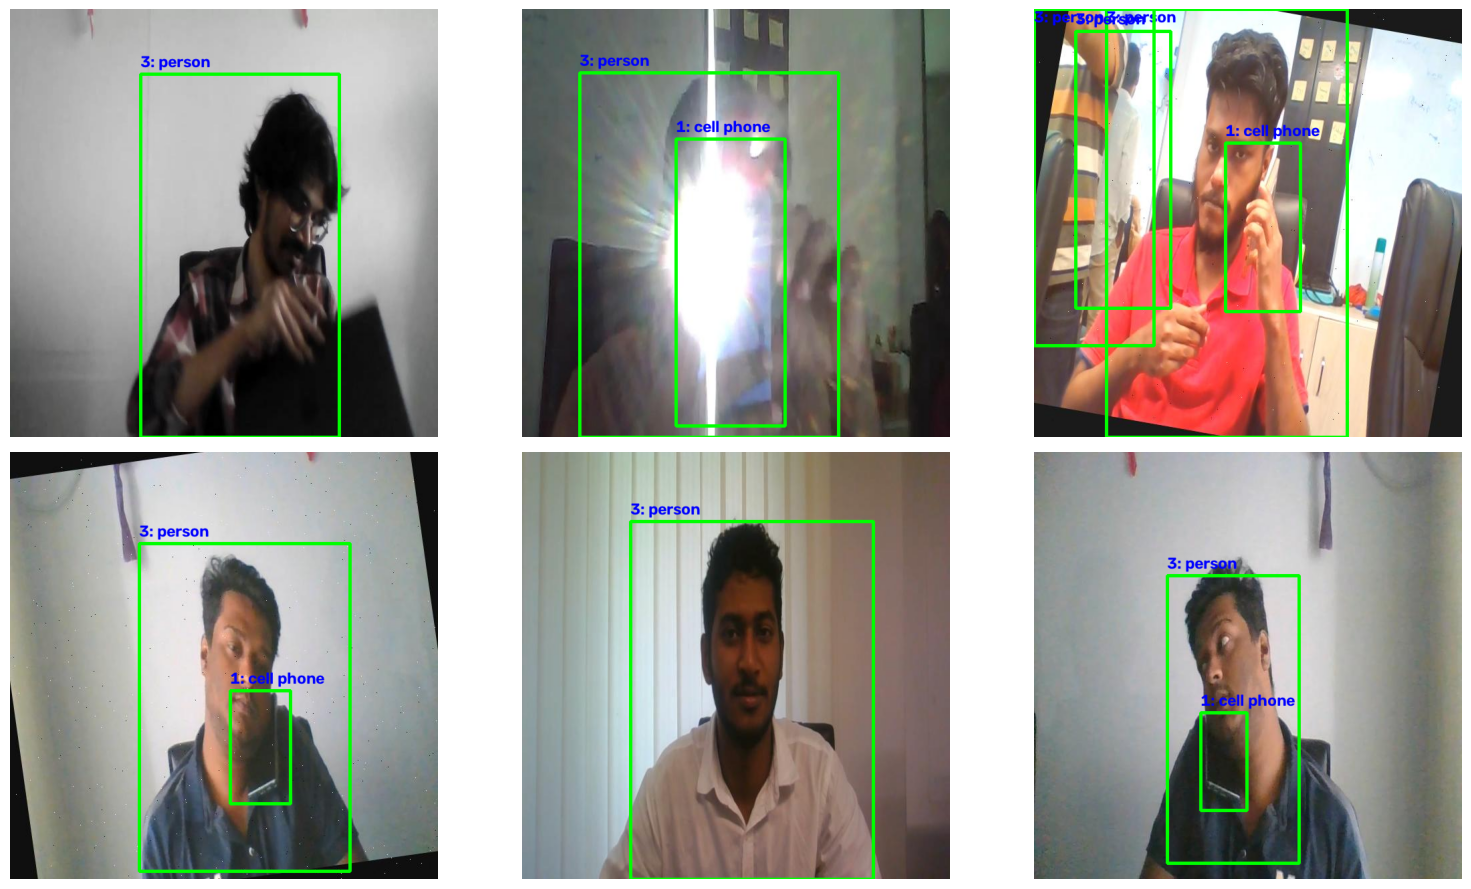

In [12]:
import matplotlib.pyplot as plt
import cv2
import os
import yaml
from pathlib import Path


# Read class names from data.yaml
with open(f"{dataset_dir}/data.yaml") as f:
    data_cfg = yaml.safe_load(f)

class_names = data_cfg["names"]


def show_samples(split="train", n=6):

    img_dir = f"{dataset_dir}/{split}/images"
    lbl_dir = f"{dataset_dir}/{split}/labels"

    img_files = os.listdir(img_dir)[:n]

    fig, axes = plt.subplots(2, n // 2, figsize=(16, 9))

    for ax, fname in zip(axes.flatten(), img_files):

        # Read image
        image = cv2.imread(f"{img_dir}/{fname}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        h, w = image.shape[:2]

        # Find corresponding label file
        lbl_path = f"{lbl_dir}/{Path(fname).stem}.txt"

        if os.path.exists(lbl_path):

            with open(lbl_path) as f:

                # Each line = one object
                for line in f:

                    # YOLO format:
                    # class_id, x_center, y_center, width, height
                    box = list(map(float, line.split()))

                    # Get class ID
                    class_id = int(box[0])

                    # Get class name
                    class_name = class_names[class_id]

                    # Convert YOLO coordinates to pixel coordinates
                    _, x1, y1, x2, y2 = yolo_to_pixel(
                        box,
                        img_w=w,
                        img_h=h
                    )

                    # Draw bounding box
                    cv2.rectangle(
                        image,
                        (x1, y1),
                        (x2, y2),
                        (0, 255, 0),
                        3
                    )

                    # Text to display
                    label = f"{class_id}: {class_name}"

                    # Draw class name
                    cv2.putText(
                        image,
                        label,
                        (x1, max(y1 - 10, 20)),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.8,
                        (0, 0, 255),
                        2
                    )

        # Display image
        ax.imshow(image)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_samples("train", 6)

## 5. Model Training

Fine-tune a YOLOv8n (nano) model, starting from COCO-pretrained weights,
on the 4-class exam-proctoring dataset.

### 5.1 Install Ultralytics

In [13]:
!pip install ultralytics
from ultralytics import YOLO

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 6.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


### 5.2 Train YOLOv8n

Training configuration: 100 epochs, image size 640, batch size 16.

In [ ]:
import torch

model = YOLO("yolov8n.pt")

results = model.train(
    data=f"{dataset_dir}/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16
)

Ultralytics 8.4.150 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Online-Proctoring-System-4class/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=None

## 6. Model Checkpoint Loading

The next cells load the best checkpoint produced by training and re-load
it from a few different saved locations (as used interchangeably across
Colab sessions during iterative experimentation).

In [ ]:
model = YOLO("/content/runs/detect/train-3/weights/best.pt")

In [ ]:
model.save("yolo_v12.pt")

In [ ]:
model = YOLO("/content/yolo_v12.pt")

In [14]:
model = YOLO("/content/best.pt")

## 7. Model Evaluation & Inference

Run the trained model against held-out data and visually inspect the
predictions.

### 7.1 Run Inference on the Full Test Set

In [17]:
results = model.predict(
    source=f"{dataset_dir}/test/images",
    imgsz=640,
    conf=0.25,
    save=True
)


image 1/911 /content/Online-Proctoring-System-4class/test/images/final-2_mp4-0037_jpg.rf.5d936e582b4544696574670f20a1987b.jpg: 640x640 1 cell phone, 2 persons, 973.1ms
image 2/911 /content/Online-Proctoring-System-4class/test/images/final-2_mp4-0047_jpg.rf.1d58119d4c3d86e26cf15874158bb9ea.jpg: 640x640 1 cell phone, 2 persons, 420.4ms
image 3/911 /content/Online-Proctoring-System-4class/test/images/final-2_mp4-0048_jpg.rf.32bf2fe88a1d887208e8ad3e312c582f.jpg: 640x640 1 cell phone, 2 persons, 395.3ms
image 4/911 /content/Online-Proctoring-System-4class/test/images/final-2_mp4-0056_jpg.rf.e19c024195f3c0e7a8b8451425774023.jpg: 640x640 1 cell phone, 3 persons, 349.4ms
image 5/911 /content/Online-Proctoring-System-4class/test/images/final-2_mp4-0057_jpg.rf.b0b78465f73b0f52426deffee06b110c.jpg: 640x640 1 cell phone, 3 persons, 467.6ms
image 6/911 /content/Online-Proctoring-System-4class/test/images/final-2_mp4-0061_jpg.rf.703f0e430692a5d21b21a5de13075b02.jpg: 640x640 1 cell phone, 3 persons,

### 7.2 Visualize a Random Sample of Predictions

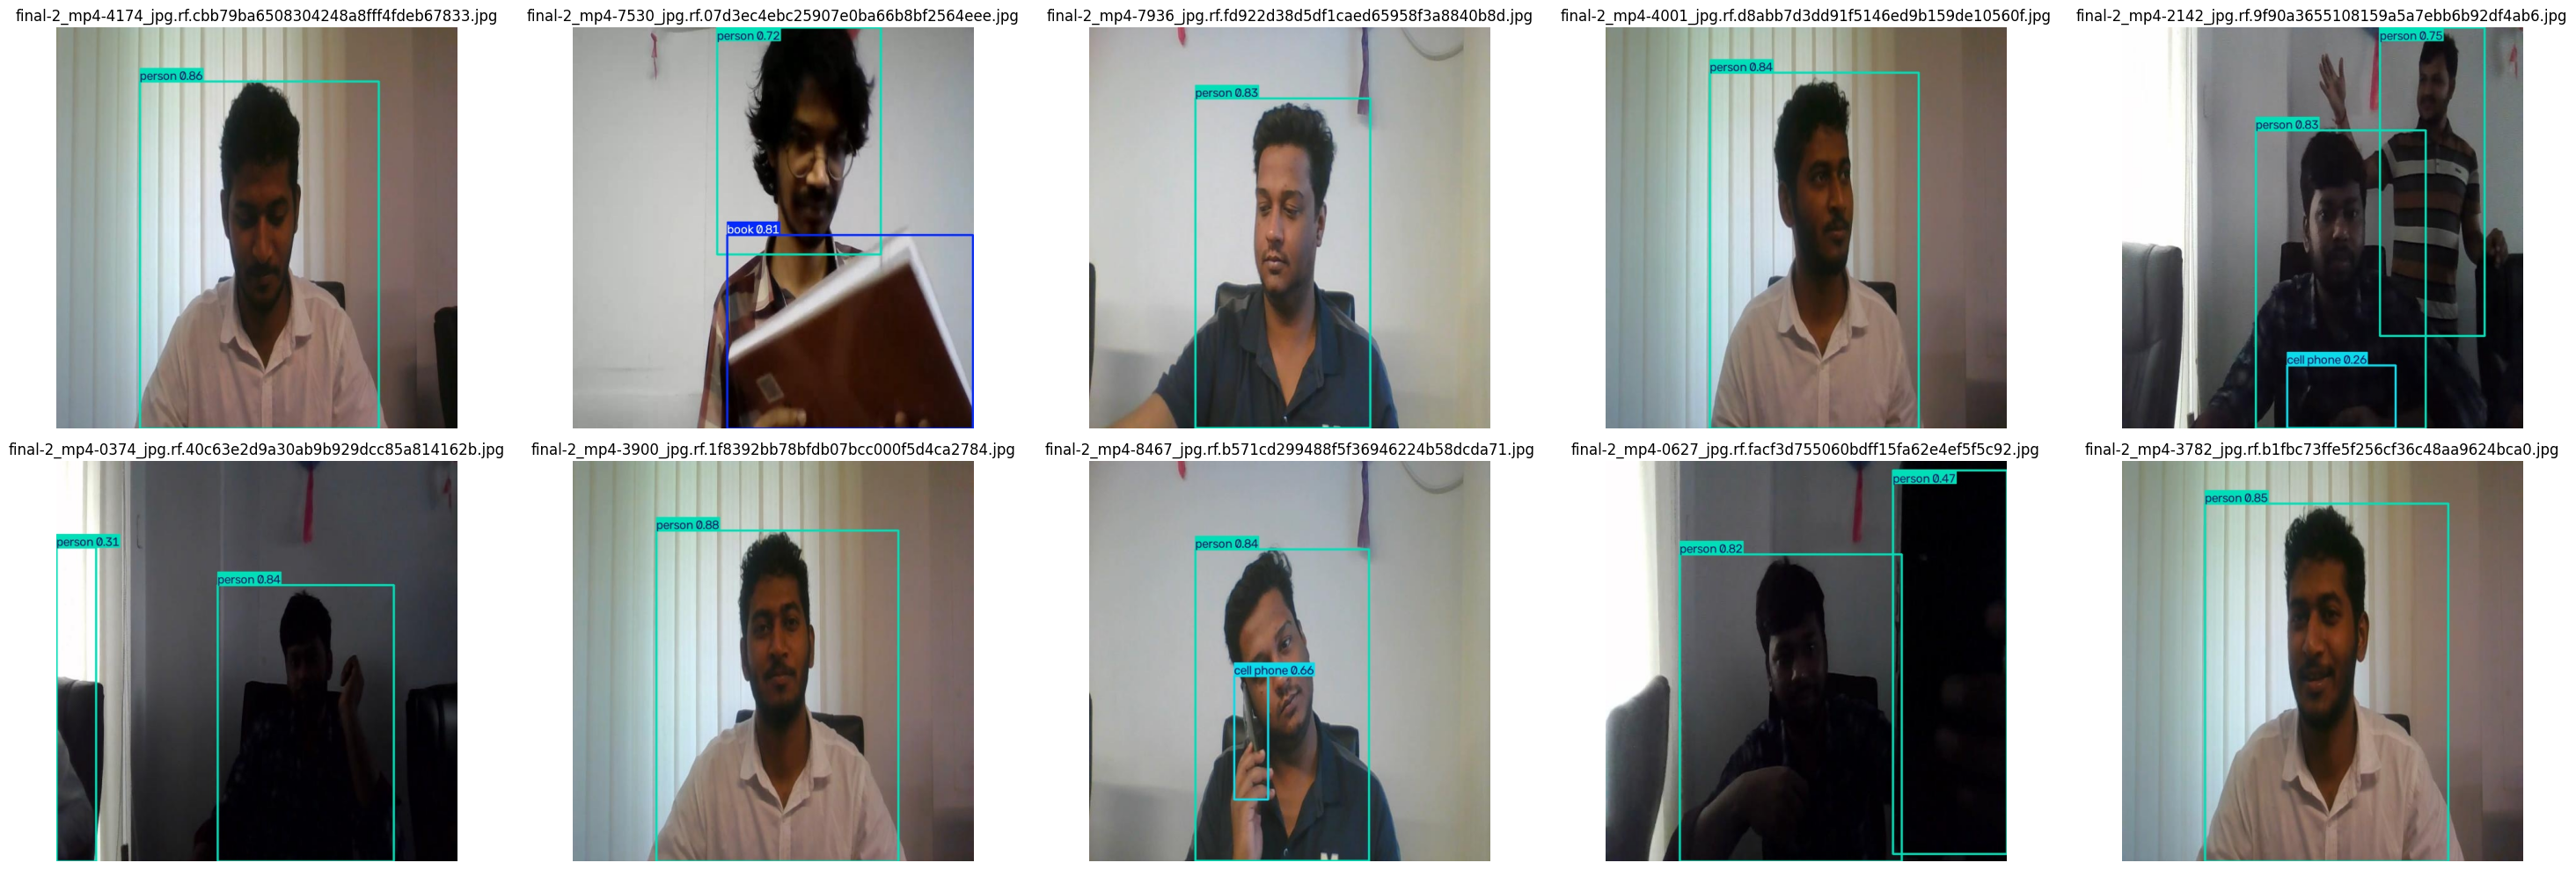

In [25]:
import random
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

predict_dir = Path(results[0].save_dir)

images = list(predict_dir.glob("*.jpg"))

random_images = random.sample(images, min(10, len(images)))

fig, axes = plt.subplots(2, 5, figsize=(30, 10))

for ax, image_path in zip(axes.flat, random_images):
    img = Image.open(image_path)

    ax.imshow(img)
    ax.set_title(image_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

### 7.3 Inspect a Single Prediction Result

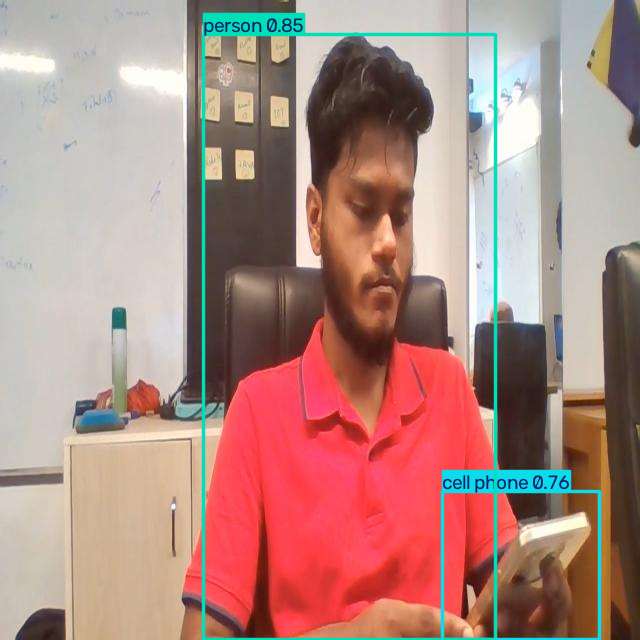

In [34]:
results[684].show()

### 7.4 Single-Image Inference Example

In [35]:
result = model.predict(
    source="/content/Online-Proctoring-System-3/test/images/final-2_mp4-0037_jpg.rf.5d936e582b4544696574670f20a1987b.jpg",
    save = False
)


image 1/1 /content/Online-Proctoring-System-3/test/images/final-2_mp4-0037_jpg.rf.5d936e582b4544696574670f20a1987b.jpg: 640x640 1 cell phone, 2 persons, 193.1ms
Speed: 5.2ms preprocess, 193.1ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


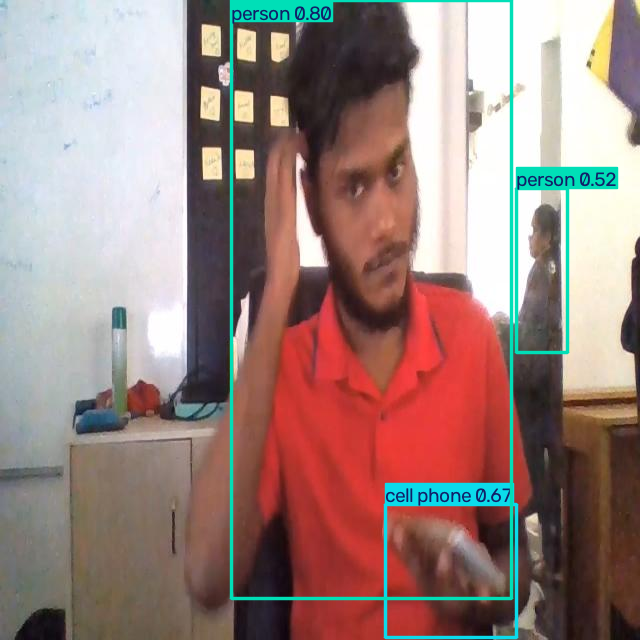

In [37]:
result[0].show()

## Summary

- Dataset reduced from 6 classes to the 4 classes relevant to exam-integrity
  risk (`book`, `cell phone`, `headphone`, `person`); `laptop` and `tv` were
  dropped since they are not suspicious in this setup.
- YOLOv8n trained for 100 epochs at 640px on the 4-class dataset.
- Trained weights (`best.pt`) validated qualitatively via random test-set
  predictions and a single-image inference example.

**Next step:** integrate this model's inference call into
`src/object_detector.py` of the main `smart_exam_proctoring` pipeline.